<h1>MAIN DIMENSIONS</h1>

In [15]:
import math


D = 0.085                   # Diameter of the stator stack = 8.5 cm
B_delta_1 = 1.1             # Peak fundamental air gap flux density = 1 T
As1rms = 40                 # Linear current density 50 kA/m
f = 50                      # Frequency of the fed current [Hz]
p = 2                       # Number of pole pairs [-]
U_l_l = 50                  # Line to line RMS voltage [V]
eta = 0.876                 # Efficiency of the motor [-]
cos_delta_s = 0.92          # Power factor [-]
n_r = 1500                  # mechanical speed of the rotor [okr/min]
P2 = 1000                   # Output mechanical power [W]
aspect_ratio = 2            # Ratio between stack length and pole pitch [-]
Do_D_ratio = 1.75            # Ratio to obtain the outer stator diameter [-]
Di = 28*1e-3                # Rotor inner shaft diameter


eta_delta = ( eta / (0.25 + 0.75 * eta) )
print(f"Eta delta  eta_delta = {eta_delta:.2f} ")
l = P2 / ( (math.pi**2 / (math.sqrt(2) * p)) * B_delta_1 * As1rms * 1000 * f * (D**2) * eta_delta * cos_delta_s )
print(f"Stack length l = {l:.2f} m" )
delta = ( 0.2 + 0.03*math.sqrt((D*1e3 * l*1e3 ) / 2) ) * 1e-3   # This is meters now [m]
print(f"Air gap length  delta = {delta * 1e3:.2f} mm")
T_n = (P2 / (n_r * math.pi) ) * 30
print(f"Nominal Torque  Tn = {T_n:.2f} Nm")
tau_p = l / aspect_ratio
print(f"Pole pitch tau_p = {tau_p:.2f} m")
Do = Do_D_ratio * D
print(f"Outer Diameter of the stator Do = {Do:.2f} m")





Eta delta  eta_delta = 0.97 
Stack length l = 0.02 m
Air gap length  delta = 1.08 mm
Nominal Torque  Tn = 6.37 Nm
Pole pitch tau_p = 0.01 m
Outer Diameter of the stator Do = 0.15 m


<h1> DETERMINATION OF THE PERMANENT MAGNET OPERATING POINT </h1>

In [16]:
#To start the calculation a magnet material needs to be selected first. Choice for today is N40 Neodymium from Arnold Magnetic Technologies available at: https://www.arnoldmagnetics.com/products/neodymium-iron-boron-magnets/

#Extracted from the datasheet:
Br = 1250e-3                        # Remanence [T]
Hc = 951e3                          # Coercivity [A/M]
#Choosen as a free parameter:
B_delta_m = 0.85                    # Air gap flux density [T]
mi_0 = 4 * math.pi * 1e-7           # Permeability of free space [H/m]
k_c = 1.02                          # Carter factor [-] , see Chapter 13
k_sat = 1.2                         # Saturation factor [-], see Chapter 13
h_m__delta_marked_ratio = 3         # Ration of magnet thickness and delta_m [-]
alpha_m = 130                       # Electrical span of the magnet pole [°]
mi_r = Br / (Hc * mi_0)             # Relative permeability [H/m]
print(f"Relative permeability mi_r = {mi_r:.2f} H/m")
delta_marked = k_c * k_sat * delta  # Virtual representation of the air gap [m]
print(f"Delta marked delta_marked = {delta_marked * 1e3:.3f} mm")
B_delta_m_1 = (4/math.pi) * B_delta_m * math.sin((alpha_m / 2) * (math.pi / 180))                     # Fundamental component of the air gap flux density of the magnet [T]
print(f"Fundamental component of permanent magnet air gap flux density B_delta_m_1 = {B_delta_m_1:.2f} T")
h_m = (delta_marked * mi_r) / ((Br / B_delta_m) - 1)    #Thickness of the magnet [m]
print(f"Thickness of the permanent magnet  h_m = {h_m * 1e3:.2f} mm")
b_m = math.radians(alpha_m) * (D / (2*p))         # Width of the magnet [m]
print(f"Width of the permanent magnet  b_m = {b_m:.2f} m")



Relative permeability mi_r = 1.05 H/m
Delta marked delta_marked = 1.323 mm
Fundamental component of permanent magnet air gap flux density B_delta_m_1 = 0.98 T
Thickness of the permanent magnet  h_m = 2.94 mm
Width of the permanent magnet  b_m = 0.05 m


<h1> CHOICE OF THE SLOT/POLE COMBINATION</h1>

In [17]:
# SWAT-EM is used for a quick preview of possible combinations and based on some research online fractional slot windings seems to do the best in regards to cogging torque which will later be important when implementing control algorithms
from fractions import Fraction
Q_s = 18                                # Number of slots [-]
m = 3                                   # Number of phases [-]
q = Q_s / (2*p*m)                       # Number of slots per pole per phase [-]
frac_q = Fraction(q).limit_denominator()
a_q = frac_q.numerator
b_q = frac_q.denominator
y = 4                                   # Coil pitch [-]
tau_p_slots = Q_s / (2*p)
print(f"Number of slots per pole per phase q = {q:.2f} ")
t = 2                                   # Greatest common denominator GCD(Q_s, p) = GCD(18, 2) = 2
Q_t = Q_s / t                           # Number of voltage phasors [-]
print(f"Number of voltage phasors Q_t = {Q_t} ")
alpha = p * 360 / Q_s                   # Electrical degree between two consecutive slots [°]
print(f"Electrical degree between two consecutive slots is {alpha:.2f} °")
q_marked = Q_s / (m*t)                  # Apparent number of slots per pole per phase [-]
print(f"Apparent number of slots per pole per phase q_marked = {q_marked} ")
alpha_marked = 180 / (m * q_marked)     # Apparent electrical degree between consecutive slots [°]
print(f"Apparent electrical degree between two consecutive slots is = {alpha_marked} ")
f_d = math.sin(q_marked * (alpha_marked / 2) * (math.pi / 180) ) / (q_marked * math.sin((alpha_marked / 2) * (math.pi / 180) ))    #Distribution factor of the windings [-]
print(f"Distribution winding factor fd = {f_d:.2f} ")
f_p = math.sin((y / tau_p_slots) * (math.pi/2) )
print(f"Pitch winding factor = {f_p:.2f} ")
f_w = f_d * f_p
print(f"Winding factor f_w = {f_w:.3f} ")
C_t = (2*p*Q_s) / math.lcm(Q_s,2*p)     # Goodness factor (lower values indicate smaller values of cogging torque)
print(f"Goodness factor C_t = {C_t:.2f} ")
p_marked = 2*p / b_q
print(f"Number of radial force pole pairs p_marked = {p_marked} ")

Number of slots per pole per phase q = 1.50 
Number of voltage phasors Q_t = 9.0 
Electrical degree between two consecutive slots is 40.00 °
Apparent number of slots per pole per phase q_marked = 3.0 
Apparent electrical degree between two consecutive slots is = 20.0 
Distribution winding factor fd = 0.96 
Pitch winding factor = 0.98 
Winding factor f_w = 0.945 
Goodness factor C_t = 2.00 
Number of radial force pole pairs p_marked = 2.0 


<h1>SKEWING OF STATOR SLOTS OR ROTOR MAGNETS</h1>

In [18]:
#For now my knowledge is not sufficient to understand how skewing will help reduce noise ripple, torque pulsation etc, so for now will be skipped

<h1>STATOR SLOT AND WINDING DESIGN</h1>

In [19]:
FRACTIONAL = 1
INTEGRAL = 0
f_fill = 0.401                              # Slot fill factor [-]
a = 2                                       # Number of parallel paths [-]
cos_phi = cos_delta_s * 0.01 + cos_delta_s  # Corrected cos_delta for 1 %
J = 5 * 1e6                                 # Current density [A/mm^2], 1e6 to put it into [A/m^2]
if FRACTIONAL:
    if (2*p) % (a*b_q) != 0:
        raise ValueError("Not enough radial force available")
if INTEGRAL:
    if (2*p) % a != 0:
        raise ValueError("Not enough radial force available")

U = U_l_l / math.sqrt(3)                # RMS phase voltage in Y configuration [V]
print(f"RMS phase voltage in Y configuration U = {U:.2f} V")
E = 0.98 * U * cos_delta_s              # BACK-EMF voltage phasor [V], 0.98 is to include the stator resistance
print(f"Back-EMF voltage phasor E = {E:.2f} V")
Phi_m = (D * l * B_delta_m_1) / p       # Flux per pole pitch [Vs] or [Wb]
z = round(E / (2.22 * Phi_m * f_w * f))        # Number of conductors per phase connected in series [-]
z_slot = round((m * z * a) / Q_s)
print(f"Number of conductors per slot z_slot = {z_slot} ")
z = (z_slot * Q_s) / (m*a)
print(f"Number of conductors per phase connected in series z = {z:.2f} ")
Phi_m_corr = E / (2.22 * z * f_w * f)
print(f"Flux per pole pitch Phi_m = {Phi_m_corr:.6f} Vs")
B_delta_m_1_corr = (Phi_m_corr * p) / (D * l)
print(f"B_delta_m_1 = {B_delta_m_1_corr:.6f} T")
B_delta_m_corr = (math.pi / 4) * B_delta_m_1_corr / math.sin((alpha_m / 2) * (math.pi / 180))
print(f"B_delta_m = {B_delta_m_corr:.6f} T")
h_m_corr = (delta_marked * mi_r) / ((Br / B_delta_m) - 1)
print(f"h_m = {h_m_corr * 1e3:.3f} mm")
I = P2 / (3 * U * eta * cos_phi)
print(f"I = {I:.2f} A")
q_c = I / (a*J)
print(f"Required cross section of a conductor is = {q_c*1e6:.9f} mm^2")
S_Cu = z_slot * q_c
print(f"Cross sectional area of the copper is S_Cu = {S_Cu*1e6:.2f} mm^2")
S_slot = S_Cu / f_fill
print(f"Total are of the slot S_slot = {S_slot*1e6} mm^2 ")

RMS phase voltage in Y configuration U = 28.87 V
Back-EMF voltage phasor E = 26.03 V
Number of conductors per slot z_slot = 98 
Number of conductors per phase connected in series z = 294.00 
Flux per pole pitch Phi_m = 0.000844 Vs
B_delta_m_1 = 0.978440 T
B_delta_m = 0.847907 T
h_m = 2.941 mm
I = 14.19 A
Required cross section of a conductor is = 1.418587279 mm^2
Cross sectional area of the copper is S_Cu = 139.02 mm^2
Total are of the slot S_slot = 346.6871654079662 mm^2 


<h2> Matlab Script for slot dimensions </h2>

In [20]:
# INPUT DATA
# All input and output dimensions are in meters
bo=2.5e-3                                       #Slot opening width
ho=0.64e-3                                      #Slot opening height
rc2=1.2e-3                                      #Curvature radius at the bottom of the slot
D=D                                             #Stator bore diameter
Qs=Q_s                                          #Number of stator slots

bt=6e-3                                       #Tooth width
#Check if the bt is in the desired range
if not ( (bt >= (0.4*D*math.pi) / Qs) & (bt < (0.6*D*math.pi) / Qs) ):
    raise ValueError("bt value out of range")
print(f"bt = {bt:.4f} m")
hs=26.5e-3                                        #Total slot height

Rs=D/2
alphao=2*math.asin(0.5*bo/Rs)                   #Slot opening in rad
thetas=2*math.pi/Qs
x1=bo/2
y1=Rs*math.cos(alphao*0.5)
x2=x1
y2=y1+ho
deltar=bt/(2*math.sin(thetas*0.5))
a1=math.cos(thetas*0.5)**2
b1=2*(deltar*math.sin(thetas*0.5)**2-Rs*math.cos(alphao*0.5)-ho)
c1=bo**2*0.25+(Rs*math.cos(alphao*0.5)+ho)**2-deltar**2*math.sin(thetas*0.5)**2
q1=(-b1+math.sqrt(b1**2-4*a1*c1))/(2*a1)
rc1=math.sqrt(x2**2+(q1-y2)**2)
x3=0.5*math.sin(thetas)*(q1-deltar)
y3=-x3*math.tan(thetas*0.5)+q1
bs=2*(Rs+hs)*math.tan(thetas*0.5)-bt/math.cos(thetas*0.5) #slot width
gama=math.atan(2*(Rs-deltar+hs)/bs)
p2=bs*0.5-rc2/math.tan(gama*0.5)
q2=Rs+hs-rc2
y4=1/(1+math.tan(thetas*0.5)**2)*(q2+p2*math.tan(thetas*0.5)+deltar*math.tan(thetas*0.5)**2)
x4=(q2-y4)*(1/math.tan(thetas*0.5))+p2
x5=bs*0.5-rc2/math.tan(gama*0.5)
y5=Rs+hs
alpha1=math.atan(x3/(q1-y3))
alpha2=math.atan(x2/(q1-y2))
alpha3=math.atan((bs*0.5-x5)/rc2)
S11=rc1**2*alpha1-0.5*rc1**2*math.sin(2*alpha1)-rc1**2*alpha2+0.5*rc1**2*math.sin(2*alpha2)
S21=-rc2*(bs*0.5-x5)+rc2**2*alpha3
A=2*(y4-y3)/(x4-x3)
B=y3-y5+(-x3+0.5*bs)*(y4-y3)/(x4-x3)
C=-S21+S11-0.5*bs*y5-x3*y3+(x3+0.5*bs)*(y3-(y4-y3)/(x4-x3)*x3)
x6=(-B+math.sqrt(B**2-4*A*C))/(2*A)
y6=y3+(y4-y3)/(x4-x3)*(x6-x3)

#OUTPUT DATA
#Slot dimensions
h1=y3-y2
print(f"h1 = {h1:.3f} m")
h2=y6-y3
print(f"h2 = {h2:.3f} m")
h3=y5-y6
print(f"h3 = {h3:.3f} m")
b1=2*x3
print(f"b1 = {b1:.3f} m")
b2=2*x6
print(f"b2 = {b2:.3f} m")
#bs is previously defined in the code
print(f"bs = {b2:.3f} m")
#Area of the top half of the slot, mm^2
S1=(S11+(x3+x6)*(y6-y3))*1e6
print(f"S1 = {S1:.3f} mm^2")
#Area of the bottom half of the slot, mm^2
S2=(S21+0.5*(bs+2*x6)*(y5-y6))*1e6
print(f"S2 = {S2:.3f} mm^2")
#S1 and S2 must be equal
#Total area of the slot
Sslot=S1+S2
print(f"Sslot = {Sslot:.3f} mm^2")


bt = 0.0060 m
h1 = 0.004 m
h2 = 0.011 m
h3 = 0.011 m
b1 = 0.011 m
b2 = 0.014 m
bs = 0.014 m
S1 = 173.179 mm^2
S2 = 173.179 mm^2
Sslot = 346.358 mm^2


<h1> DESIGN OF THE MAGNETIC CIRCUIT </h1>


B(5000) = 1.6807764337250093


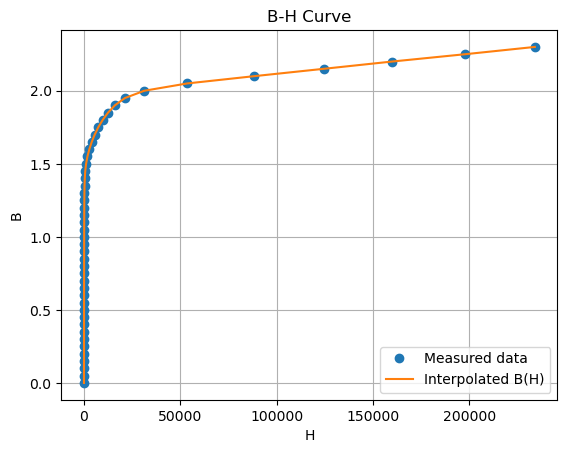

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# -------------------------
# Raw data
# Column 1: B
# Column 2: H
# -------------------------
B = np.array([
    0.000000,0.050000,0.100000,0.150000,0.200000,0.250000,0.300000,0.350000,
    0.400000,0.450000,0.500000,0.550000,0.600000,0.650000,0.700000,0.750000,
    0.800000,0.850000,0.900000,0.950000,1.000000,1.050000,1.100000,1.150000,
    1.200000,1.250000,1.300000,1.350000,1.400000,1.450000,1.500000,1.550000,
    1.600000,1.650000,1.700000,1.750000,1.800000,1.850000,1.900000,1.950000,
    2.000000,2.050000,2.100000,2.150000,2.200000,2.250000,2.300000
])

H = np.array([
    0.000000,15.120714,22.718292,27.842733,31.871434,35.365044,38.600588,
    41.736202,44.873979,48.087807,51.437236,54.975221,58.752993,62.823644,
    67.245285,72.084406,77.420100,83.350021,89.999612,97.537353,106.201406,
    116.348464,128.547329,143.765431,163.754169,191.868158,234.833507,
    306.509769,435.255202,674.911968,1108.325569,1813.085468,2801.217421,
    4053.653117,5591.106890,7448.318413,9708.815670,12486.931615,
    16041.483644,21249.420624,31313.495878,53589.446877,88477.484601,
    124329.410540,159968.569300,197751.604272,234024.751347
])

# -------------------------
# Interpolation: B(H)
# -------------------------
B_from_H = interp1d(
    H,
    B,
    kind='linear',          # 'cubic' or 'pchip' optional
    fill_value="extrapolate"
)
H_from_B = interp1d(
    B,
    H,
    kind='linear', fill_value="extrapolate"
)

# Example usage
H_test = 5000
print(f"B({H_test}) = {B_from_H(H_test)}")

# -------------------------
# Plot (H on x-axis, B on y-axis)
# -------------------------
plt.figure()
plt.plot(H, B, 'o', label='Measured data')
plt.plot(H, B_from_H(H), '-', label='Interpolated B(H)')

plt.xlabel("H")
plt.ylabel("B")
plt.title("B-H Curve")
plt.grid(True)
plt.legend()
plt.show()


In [22]:
#For an SMPM motor instead of delta for the Carter factors formula we need to use (d+hm)/mi_rm
k_fe = 0.95                                                                                 #Stacking factor that takes insulation of the stator core in the calculation
delta_carter = (delta + h_m_corr) / mi_r
tau_s = (D*math.pi) / Q_s
term = (math.atan(bo / (2 * delta_carter))- (bo / (2 * delta_carter)) * math.log(1 + (bo / (2 * delta_carter))**2))
kc = tau_s / (tau_s - (2 * bo / math.pi) * term)                                            #Carter factor
print(f"kc = {kc:.3f}")
V_delta_smooth = B_delta_m_corr*delta/mi_0                                                  #Air-gap MMF
print(f"V_delta_smooth = {V_delta_smooth:.1f} A")
V_delta_slotted = kc * V_delta_smooth                                                       #Air-gap MMF adjusted for the slotted stator
print(f"V_delta_slotted = {V_delta_slotted:.1f} A")
B_t_marked = (B_delta_m_corr*tau_s) / (k_fe*bt)                                             #Apparent tooth flux density
print(f"B_t_marked = {B_t_marked:.1f} T")
k_t = tau_s/(k_fe*bt) - 1                                                                   #Tooth line
print(f"k_t = {k_t:.1f} ")


kc = 1.031
V_delta_smooth = 729.4 A
V_delta_slotted = 752.1 A
B_t_marked = 2.2 T
k_t = 1.6 


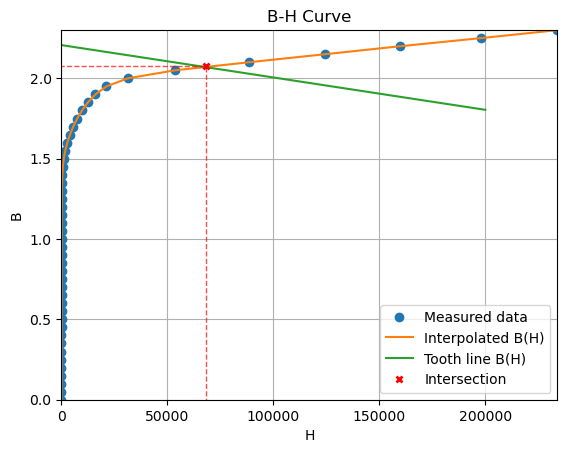

B_t = 2.1 T


In [23]:
#Graphical method is used to determine the tooth flux density, this is just an example
H_t = np.linspace(0,200000, 1000)
B_t_marked_plot = np.full(len(H_t), B_t_marked)
B_t = B_t_marked_plot - k_t*mi_0*H_t
plt.figure()
plt.plot(H, B, 'o', label='Measured data')
plt.plot(H, B_from_H(H), '-', label='Interpolated B(H)')
plt.plot(H_t, B_t, '-', label='Tooth line B(H)')
# Mark the intersection point with X marker
H_intersection = 68000
B_intersection = 2.075
plt.plot(H_intersection, B_intersection, 'rx', markersize=5, markeredgewidth=2, label='Intersection')
# Draw dotted lines to axes
plt.plot([H_intersection, H_intersection], [plt.ylim()[0], B_intersection], 'r--', linewidth=1, alpha=0.7)
plt.plot([plt.xlim()[0], H_intersection], [B_intersection, B_intersection], 'r--', linewidth=1, alpha=0.7)

plt.xlim(0,max(H))
plt.ylim(0,max(B))
plt.xlabel("H")
plt.ylabel("B")
plt.title("B-H Curve")
plt.grid(True)
plt.legend()
plt.show()
B_t = B_intersection
print(f"B_t = {B_t:.1f} T")



In [24]:
#Section I
bt_I = tau_s - bo
Bt_I_marked = (B_delta_m_corr*tau_s)/(k_fe*bt_I)
print(f"Bt_I_marked = {Bt_I_marked:.1f} T")
if not (Bt_I_marked < 1.8):
    raise ValueError("A graph method needs to be performed")
Bt_I = Bt_I_marked
H_t_I = H_from_B(Bt_I)
V_t_I = H_t_I*ho
print(f"H_t_I = {H_t_I:.1f} A/m")
print(f"Bt_I = {Bt_I:.1f} T")
print(f"V_t_I = {V_t_I:.2f} A")



Bt_I_marked = 1.1 T
H_t_I = 122.1 A/m
Bt_I = 1.1 T
V_t_I = 0.08 A


Bt_II_h1_half = 1.44 T
Ht_II_h1_half = 647.68 A/m


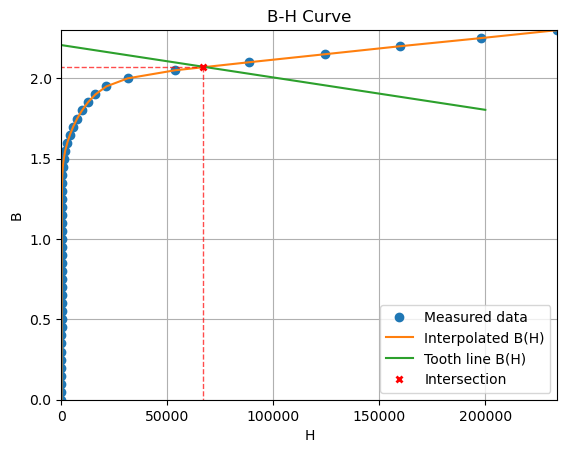

Bt_II_h1 = 2.070 T
Ht_II_h1 = 67000.0 A/m
V_t_II = 50.145 A


In [25]:
#Section II
#Section II is split in three locations and then MMF drop is approximated using Simpson formula
from typing import Any
# y = 0
Bt_II_0 = Bt_I
Ht_II_0 = H_t_I
# y = h1 / 2
bt_II_h1_half = (bt_I + bt)*0.5
Bt_II_h1_half_marked = B_delta_m_corr*tau_s/(k_fe*bt_II_h1_half)
if not (Bt_II_h1_half_marked < 1.8):
    raise ValueError("A graph method needs to be performed")
Bt_II_h1_half = Bt_II_h1_half_marked
Ht_II_h1_half = H_from_B(Bt_II_h1_half)
print(f"Bt_II_h1_half = {Bt_II_h1_half:.2f} T")
print(f"Ht_II_h1_half = {Ht_II_h1_half:.2f} A/m")
# y = h1
bt_II_h1 = bt
Bt_II_h1_marked = B_delta_m_corr*tau_s/(k_fe*bt_II_h1)
Bt_II_h1 = Any
Ht_II_h1 = Any
if not (Bt_II_h1_marked < 1.8):

    H_t = np.linspace(0,200000, 1000)
    B_t_marked_plot = np.full(len(H_t), Bt_II_h1_marked)
    B_t = B_t_marked_plot - k_t*mi_0*H_t
    plt.figure()
    plt.plot(H, B, 'o', label='Measured data')
    plt.plot(H, B_from_H(H), '-', label='Interpolated B(H)')
    plt.plot(H_t, B_t, '-', label='Tooth line B(H)')
    # Mark the intersection point with X marker
    H_intersection = 67000
    B_intersection = 2.07
    plt.plot(H_intersection, B_intersection, 'rx', markersize=5, markeredgewidth=2, label='Intersection')
    # Draw dotted lines to axes
    plt.plot([H_intersection, H_intersection], [plt.ylim()[0], B_intersection], 'r--', linewidth=1, alpha=0.7)
    plt.plot([plt.xlim()[0], H_intersection], [B_intersection, B_intersection], 'r--', linewidth=1, alpha=0.7)

    plt.xlim(0,max(H))
    plt.ylim(0,max(B))
    plt.xlabel("H")
    plt.ylabel("B")
    plt.title("B-H Curve")
    plt.grid(True)
    plt.legend()
    plt.show()
    Bt_II_h1 = B_intersection
    Ht_II_h1 = H_intersection

print(f"Bt_II_h1 = {Bt_II_h1:.3f} T")
print(f"Ht_II_h1 = {Ht_II_h1:.1f} A/m")

V_t_II = (h1/6)*(Ht_II_0 + 4 * Ht_II_h1_half + Ht_II_h1)
print(f"V_t_II = {V_t_II:.3f} A")




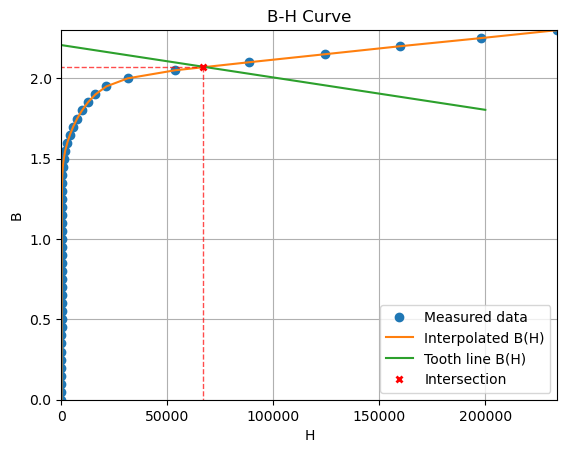

Bt_III = 2.070 T
Ht_III = 67000.0 A/m
V_t_III = 1444.689 A


In [26]:
#Section III
bt_III = bt
Bt_III_marked = B_delta_m_corr*tau_s/(k_fe*bt_III)
Bt_III = Any
Ht_III = Any
if not (Bt_III_marked < 1.8):
        H_t = np.linspace(0,200000, 1000)
        B_t_marked_plot = np.full(len(H_t), Bt_III_marked)
        B_t = B_t_marked_plot - k_t*mi_0*H_t
        plt.figure()
        plt.plot(H, B, 'o', label='Measured data')
        plt.plot(H, B_from_H(H), '-', label='Interpolated B(H)')
        plt.plot(H_t, B_t, '-', label='Tooth line B(H)')
        # Mark the intersection point with X marker
        H_intersection = 67000
        B_intersection = 2.07
        plt.plot(H_intersection, B_intersection, 'rx', markersize=5, markeredgewidth=2, label='Intersection')
        # Draw dotted lines to axes
        plt.plot([H_intersection, H_intersection], [plt.ylim()[0], B_intersection], 'r--', linewidth=1, alpha=0.7)
        plt.plot([plt.xlim()[0], H_intersection], [B_intersection, B_intersection], 'r--', linewidth=1, alpha=0.7)

        plt.xlim(0,max(H))
        plt.ylim(0,max(B))
        plt.xlabel("H")
        plt.ylabel("B")
        plt.title("B-H Curve")
        plt.grid(True)
        plt.legend()
        plt.show()
        Bt_III = B_intersection
        Ht_III = H_intersection

print(f"Bt_III = {Bt_III:.3f} T")
print(f"Ht_III = {Ht_III:.1f} A/m")
V_t_III = Ht_III*(h2+h3)
print(f"V_t_III = {V_t_III:.3f} A")




In [27]:
V_t = V_t_I + V_t_II + V_t_III                                      #Total MMF drop in the tooth
print(f"V_t = {V_t:.3f} A")

V_t = 1494.912 A


In [34]:
#Stator and rotor yoke MMF drop
#Assumed variables--------------
Dr = 77e-3
#-----------------------


h_ys = (Do - (D + 2*22e-3)) * 0.5     #I should aim for the height to be 22 mm otherwise I would get too high of a field strength
print(f"h_ys = {h_ys:.3f} m")
h_yr = (Dr - Di) / 2
print(f"h_yr = {h_yr:.3f} m")
B_ys = Phi_m_corr / (2*k_fe*h_ys*l)
print(f"B_ys = {B_ys:.3f} T")
B_yr = Phi_m_corr / (2*k_fe*h_yr*l)
print(f"B_yr = {B_yr:.3f} T")


h_ys = 0.010 m
h_yr = 0.025 m
B_ys = 2.216 T
B_yr = 0.893 T
